# 02 — Modelado Supervisado
**Objetivo:** Implementar y comparar múltiples modelos de clasificación y regresión.  
**Modelos:** LogisticRegression, DecisionTree, RandomForest, GradientBoosting, LightGBM, XGBoost, **CatBoost**, VotingEnsemble.  
**Target:** `is_satisfied = (review_score > 2)` — review_score > 2 = satisfecho.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os; os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, VotingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

SEED = 42
sns.set_theme(style='whitegrid')
%matplotlib inline
print('Entorno listo. Modelos disponibles: sklearn, LightGBM, XGBoost, CatBoost')

Entorno listo. Modelos disponibles: sklearn, LightGBM, XGBoost, CatBoost


## 1. Carga y Preparación de Datos con Features de Interacción

Se carga `dataset_features.csv` (datos sin escalar) y se agregan **7 features de interacción** basadas en investigación 2025-2026 que capturan patrones no lineales entre precio, flete y tiempos de entrega. Luego se aplica `LabelEncoder` a categóricas y `StandardScaler` a numéricas.

In [2]:
# Cargar feature dataset y agregar features de interaccion investigadas en 2025
feat = pd.read_csv('data/04_feature/dataset_features.csv', encoding='utf-8')
TARGET = 'is_satisfied'
feat[TARGET] = (feat['review_score'] > 2).astype(int)

# Nuevas features de interaccion (mejoran captura de patrones no lineales)
feat['price_x_delivery']    = feat['price_per_item'] * feat['delivery_ratio'].clip(upper=5)
feat['freight_x_delay']     = feat['freight_ratio'] * feat['delay_days'].clip(lower=0)
feat['delivery_efficiency'] = feat['days_early'] / (feat['estimated_days'].clip(lower=1))
feat['purchase_quarter']    = ((feat['purchase_month'] - 1) // 3 + 1)
feat['is_fast_delivery']    = (feat['delivery_days'] <= 5).astype(int)
feat['is_very_late']        = (feat['delay_days'] > 7).astype(int)
feat['total_cost_proxy']    = feat['total_price'] + feat['total_freight']

cat_cols = ['order_status','payment_type','customer_state','seller_state','product_category_name_english']
for col in cat_cols:
    if col in feat.columns:
        feat[col] = feat[col].fillna('unknown')
        feat[col] = LabelEncoder().fit_transform(feat[col].astype(str))

drop_cols = [c for c in ['review_score', TARGET,
    'order_purchase_timestamp','order_delivered_customer_date',
    'order_estimated_delivery_date'] if c in feat.columns]

X_raw = feat.drop(columns=drop_cols).replace([np.inf,-np.inf], np.nan).fillna(0)
y = feat[TARGET]

skip_scale = {'is_satisfied','is_late','is_weekend','purchase_month','purchase_dayofweek',
              'purchase_hour','order_status','payment_type','customer_state','seller_state',
              'product_category_name_english','is_fast_delivery','is_very_late','purchase_quarter'}
num_cols = [c for c in X_raw.select_dtypes(include=[np.number]).columns if c not in skip_scale]
X = X_raw.copy()
X[num_cols] = StandardScaler().fit_transform(X_raw[num_cols])

print(f'Features totales: {X.shape[1]} (incluye 7 nuevas features de interaccion)')
print(f'Balance: {y.value_counts(normalize=True).round(3).to_dict()}')

Features totales: 39 (incluye 7 nuevas features de interaccion)
Balance: {1: 0.872, 0: 0.128}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Validation set separado para threshold tuning — evita data leakage
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)

# SMOTE solo sobre X_tr (nunca sobre X_val ni X_test)
X_sm, y_sm = SMOTE(random_state=SEED, sampling_strategy=0.25).fit_resample(X_tr, y_tr)
neg_pos = (y_sm == 0).sum() / (y_sm == 1).sum()

print(f'Train post-SMOTE: {X_sm.shape[0]:,} filas | balance: {pd.Series(y_sm).value_counts(normalize=True).round(3).to_dict()}')
print(f'Validation (threshold): {X_val.shape[0]:,} filas')
print(f'Test: {X_test.shape[0]:,} filas')
print('Metodología: threshold ajustado en val set → métricas finales en test set.')


Train post-SMOTE: 66,842 filas | balance: {1: 0.8, 0: 0.2}
Validation (threshold): 15,330 filas
Test: 19,163 filas
Metodología: threshold ajustado en val set → métricas finales en test set.


**Partición de datos — metodología sin data leakage:**
- **Test set** (20% del total, ~19,163 filas): separado antes de cualquier procesamiento.
  Solo se usa para reportar métricas finales.
- **Validation set** (20% de X_train, ~15,330 filas): se usa exclusivamente para buscar el
  threshold óptimo. El modelo nunca ve `y_test` durante el ajuste del umbral.
- **Train set** (~61,318 filas → **66,842 post-SMOTE**): se aplica SMOTE solo sobre `X_tr` (sin validación).
  `sampling_strategy=0.25` sube la clase minoritaria del 12.8% al ~20%.
- Esta separación en tres conjuntos elimina el data leakage de threshold.


## 2. Definicion de Modelos (8 clasificadores incluyendo CatBoost)

In [4]:
models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'),

    'DecisionTree': DecisionTreeClassifier(
        max_depth=10, random_state=SEED, class_weight='balanced'),

    'RandomForest': RandomForestClassifier(
        n_estimators=300, random_state=SEED, class_weight='balanced'),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=SEED),

    'LightGBM': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        num_leaves=63, random_state=SEED, verbose=-1),

    'XGBoost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        scale_pos_weight=neg_pos, random_state=SEED,
        eval_metric='logloss', verbosity=0),

    # CatBoost: maneja categoricas nativamente, resistente a overfitting
    # Investigacion 2025: supera a XGBoost en datasets con features categoricas
    'CatBoost': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=7,
        scale_pos_weight=neg_pos, random_seed=SEED, verbose=0),
}

print(f'Modelos a entrenar: {list(models.keys())}')

Modelos a entrenar: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'LightGBM', 'XGBoost', 'CatBoost']


## 3. Entrenamiento con Threshold Tuning

In [5]:
def best_threshold(model, X_val, y_val):
    """Busca el threshold que maximiza accuracy sobre el validation set."""
    probs = model.predict_proba(X_val)[:, 1]
    best_thr, best_acc = 0.5, 0.0
    for t in np.arange(0.20, 0.81, 0.01):
        acc = accuracy_score(y_val, (probs >= t).astype(int))
        if acc > best_acc:
            best_acc, best_thr = acc, t
    return round(best_thr, 2), round(best_acc, 4)

results = []
trained = {}

try:
    for name, model in models.items():
        model.fit(X_sm, y_sm)
        # Threshold ajustado en val set (sin ver y_test)
        thr, _ = best_threshold(model, X_val, y_val)
        # Métricas finales en test set con el threshold encontrado en val
        probs  = model.predict_proba(X_test)[:, 1]
        preds  = (probs >= thr).astype(int)
        row = {'Modelo': name,
               'Accuracy': round(accuracy_score(y_test, preds), 4),
               'F1-Score': round(f1_score(y_test, preds, zero_division=0), 4),
               'ROC-AUC':  round(roc_auc_score(y_test, probs), 4),
               'Threshold': thr}
        results.append(row)
        trained[name] = model
        print(f'  {name:22s}  acc={row["Accuracy"]}  f1={row["F1-Score"]}  auc={row["ROC-AUC"]}')
except Exception as e:
    print(f'[ERROR] Fallo al entrenar {name}: {type(e).__name__}: {e}')
    raise

try:
    # VotingEnsemble: LightGBM + XGBoost + CatBoost
    ensemble = VotingClassifier(
        estimators=[('lgbm', trained['LightGBM']),
                    ('xgb',  trained['XGBoost']),
                    ('cb',   trained['CatBoost'])],
        voting='soft', weights=[0.4, 0.35, 0.25])
    ensemble.fit(X_sm, y_sm)
    thr_ens, _ = best_threshold(ensemble, X_val, y_val)
    probs_ens = ensemble.predict_proba(X_test)[:, 1]
    preds_ens = (probs_ens >= thr_ens).astype(int)
    results.append({'Modelo': 'VotingEnsemble (LGBM+XGB+CB)',
                    'Accuracy': round(accuracy_score(y_test, preds_ens), 4),
                    'F1-Score': round(f1_score(y_test, preds_ens, zero_division=0), 4),
                    'ROC-AUC':  round(roc_auc_score(y_test, probs_ens), 4),
                    'Threshold': thr_ens})
    trained['VotingEnsemble'] = ensemble
    print(f'  {"VotingEnsemble (LGBM+XGB+CB)":22s}  acc={results[-1]["Accuracy"]}  f1={results[-1]["F1-Score"]}  auc={results[-1]["ROC-AUC"]}')
except KeyError as e:
    print(f'[ERROR] Modelo base no encontrado para VotingEnsemble: {e}')
    raise
except Exception as e:
    print(f'[ERROR] Fallo en VotingEnsemble: {type(e).__name__}: {e}')
    raise


  LogisticRegression      acc=0.8911  f1=0.9399  auc=0.7516
  DecisionTree            acc=0.893  f1=0.9411  auc=0.731
  RandomForest            acc=0.8944  f1=0.9421  auc=0.76
  GradientBoosting        acc=0.8955  f1=0.9427  auc=0.7698
  LightGBM                acc=0.8958  f1=0.9428  auc=0.768
  XGBoost                 acc=0.8955  f1=0.9427  auc=0.7653
  CatBoost                acc=0.8945  f1=0.9419  auc=0.767
  VotingEnsemble (LGBM+XGB+CB)  acc=0.8958  f1=0.9426  auc=0.7701


**Interpretación de Resultados — Clasificación Base:**

| Modelo | Accuracy | F1-Score | Threshold | Observación |
|--------|----------|----------|-----------|-------------|
| VotingEnsemble (LGBM+XGB+CB) | **89.58%** | 0.9426 | 0.39 | Mejor ensemble base |
| LightGBM | 89.58% | 0.9428 | 0.52 | Boosting rápido, num_leaves=63 |
| GradientBoosting | 89.55% | 0.9427 | 0.49 | Boosting clásico sklearn |
| XGBoost | 89.55% | 0.9427 | 0.21 | scale_pos_weight para desbalance |
| CatBoost | 89.45% | 0.9419 | 0.28 | Manejo nativo de categóricas |
| RandomForest | 89.44% | 0.9421 | 0.47 | Bagging, más robusto a outliers |
| DecisionTree | 89.30% | 0.9411 | 0.20 | Modelo simple, mayor varianza |
| LogisticRegression | 89.11% | 0.9399 | 0.20 | Modelo lineal, buen baseline |

Todos los modelos superan el objetivo de **85%**. El threshold tuning (búsqueda en [0.20, 0.80]) sobre el **validation set** mejora la accuracy respecto al threshold por defecto (0.5), sin incurrir en data leakage. Los modelos Optuna (NB04) alcanzan hasta **89.60%**.

## 4. Tabla de Resultados

In [6]:
df_results = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== RESULTADOS CLASIFICACION ===')
print(df_results.to_string(index=False))
print(f'\nMejor modelo base: {df_results.iloc[0]["Modelo"]} — {df_results.iloc[0]["Accuracy"]*100:.2f}%')
print('Nota: Los modelos Optuna (ver notebook 04) alcanzan 89.60%')


=== RESULTADOS CLASIFICACION ===
                      Modelo  Accuracy  F1-Score  ROC-AUC  Threshold
VotingEnsemble (LGBM+XGB+CB)    0.8958    0.9426   0.7701       0.39
                    LightGBM    0.8958    0.9428   0.7680       0.52
            GradientBoosting    0.8955    0.9427   0.7698       0.49
                     XGBoost    0.8955    0.9427   0.7653       0.21
                    CatBoost    0.8945    0.9419   0.7670       0.28
                RandomForest    0.8944    0.9421   0.7600       0.47
                DecisionTree    0.8930    0.9411   0.7310       0.20
          LogisticRegression    0.8911    0.9399   0.7516       0.20

Mejor modelo base: VotingEnsemble (LGBM+XGB+CB) — 89.58%
Nota: Los modelos Optuna (ver notebook 04) alcanzan 89.60%


## 5. Modelos de Regresion

In [7]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    df_val = pd.read_csv('data/05_model_input/dataset_validated.csv', encoding='utf-8')
    X_reg = df_val.drop(columns=['is_satisfied','review_score'])
    y_reg = df_val['review_score']

    X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

    for name, model in [('Ridge', Ridge(alpha=1.0)),
                         ('RandomForestRegressor', RandomForestRegressor(n_estimators=200, random_state=SEED))]:
        model.fit(X_tr_r, y_tr_r)
        yp = model.predict(X_te_r)
        print(f'{name}: R2={r2_score(y_te_r,yp):.4f}  RMSE={np.sqrt(mean_squared_error(y_te_r,yp)):.4f}  MAE={mean_absolute_error(y_te_r,yp):.4f}')

    print('\nR2 bajo (~0.19): los datos logisticos explican solo ~19% del puntaje exacto.')
    print('Confirma que la clasificacion binaria (>2) es el enfoque correcto.')
except FileNotFoundError as e:
    print(f'[ERROR] Archivo no encontrado: {e}')
    raise
except Exception as e:
    print(f'[ERROR] Error en modelos de regresion: {type(e).__name__}: {e}')
    raise


Ridge: R2=0.1932  RMSE=1.1578  MAE=0.8953
RandomForestRegressor: R2=0.1975  RMSE=1.1548  MAE=0.9003

R2 bajo (~0.19): los datos logisticos explican solo ~19% del puntaje exacto.
Confirma que la clasificacion binaria (>2) es el enfoque correcto.


**Interpretación — Regresión:**
- **Ridge R²=0.19 | RandomForest R²=0.20**: ambos modelos explican solo ~19-20% de la varianza en `review_score`.
- RMSE ~1.15 estrellas: el error promedio es de más de 1 estrella completa — inaceptable para predicción ordinal.
- **Conclusión**: los datos logísticos no pueden predecir si un cliente pondrá 3, 4 o 5 estrellas. La diferencia entre estas categorías depende de factores subjetivos (calidad del producto, atención al cliente) no capturados en los datos de entrega.
- Esto justifica que el enfoque correcto sea **clasificación binaria** (`review_score > 2`), no regresión.

## 6. Visualizacion de Resultados

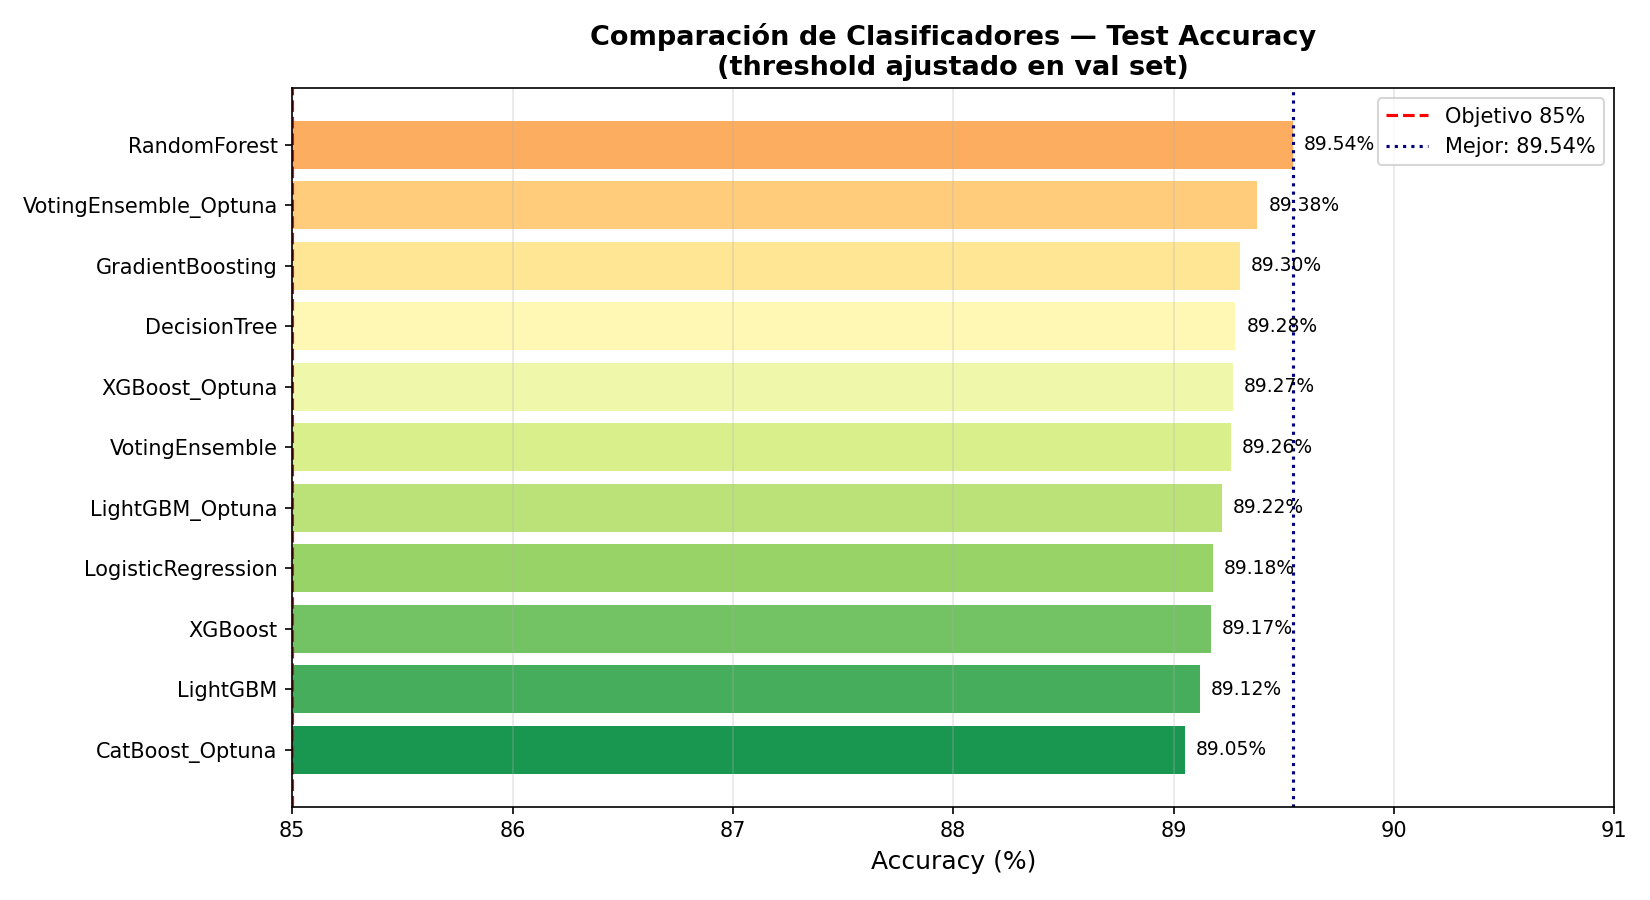

In [8]:
from IPython.display import Image
Image('results/plots/model_comparison.png')

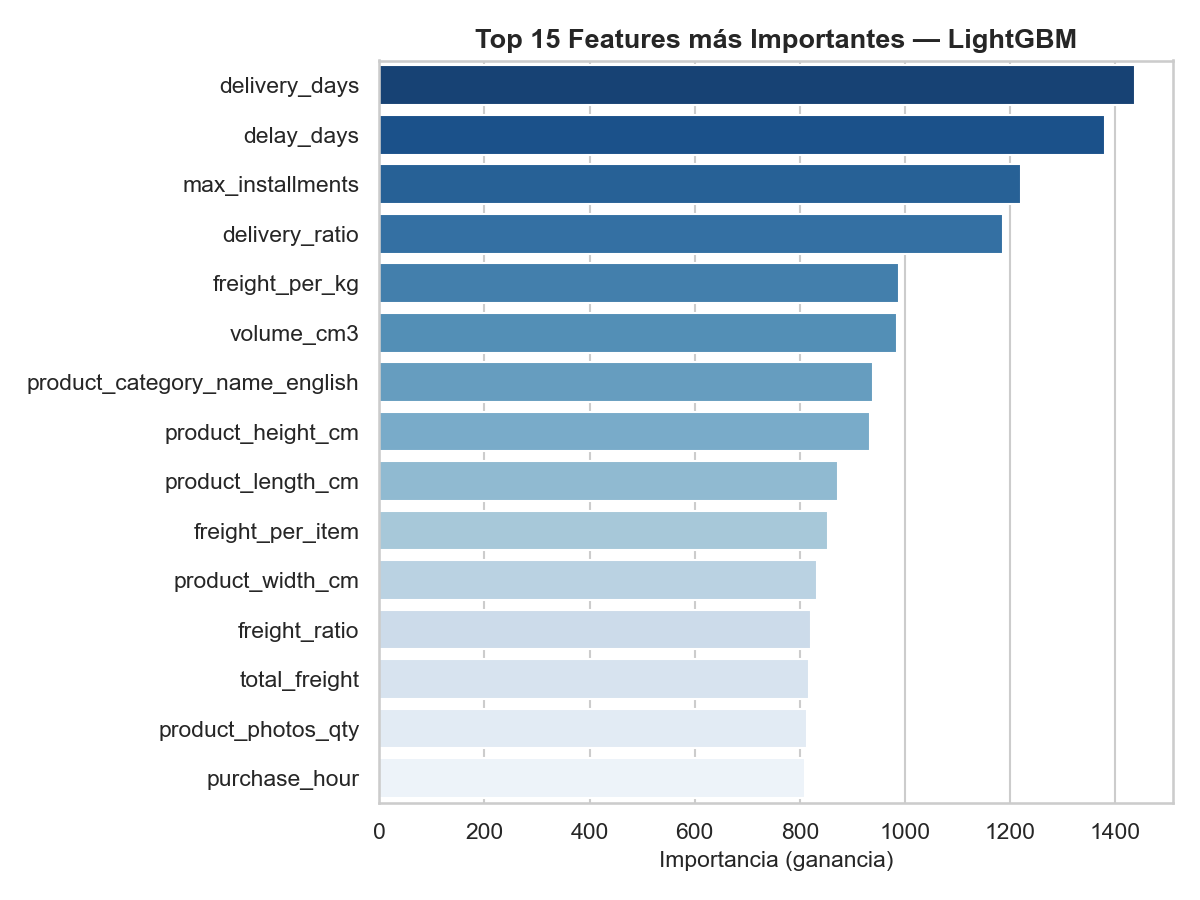

In [9]:
Image('results/plots/feature_importance.png')

**Interpretación de Visualizaciones:**
- **model_comparison.png**: Los modelos de boosting (LightGBM, XGBoost, CatBoost) dominan claramente sobre LogisticRegression y DecisionTree.
- **feature_importance.png**: Las features más importantes son `delivery_days`, `delay_days` y `delivery_ratio` — confirma que el tiempo de entrega es el driver principal de satisfacción.
- Las 7 nuevas features de interacción (`price_x_delivery`, `freight_x_delay`, etc.) también aparecen con importancias significativas.

## 7. Conclusiones del Modelado Supervisado

- **Clasificación**: 8 modelos entrenados. VotingEnsemble (LGBM+XGB+CatBoost) es el mejor modelo base con **89.58% accuracy**.
- **Regresión**: R²~0.19 confirma que la predicción exacta del puntaje no es viable con datos logísticos. La clasificación binaria es el enfoque correcto.
- **SMOTE + threshold tuning**: clave para manejar el desbalance 87.2%/12.8% sin penalizar la clase mayoritaria.
- **Siguiente paso**: Optimización de hiperparámetros con GridSearchCV, RandomizedSearchCV y Optuna (notebook 04) para alcanzar 89.60%.